In [1]:
import pandas as pd
import numpy as np
train_df = pd.read_csv("data/processed/cleaning_train.csv")
eval_df = pd.read_csv("data/processed/cleaning_eval.csv")
holdout_df = pd.read_csv("data/processed/cleaning_holdout.csv")

In [2]:
# ============================
# 3. Frequency Encoding (State)
# ============================
state_counts = train_df["State"].value_counts()

train_df["State_freq"] = train_df["State"].map(state_counts)
eval_df["State_freq"] = eval_df["State"].map(state_counts).fillna(0)
holdout_df["State_freq"] = holdout_df["State"].map(state_counts).fillna(0)

print("State freq example (train):")
print(train_df[["State", "State_freq"]].head())


'''

- On train, we build the frequency dictionary (state_counts).
- On eval, we never compute new counts → we only look up in the dictionary.
- If eval has an unseen State, it gets NaN, which we replace with 0.
'''

State freq example (train):
          State  State_freq
0      Illinois          75
1      Michigan          59
2        Kansas          74
3  Pennsylvania          40
4    Washington          30


'\n\n- On train, we build the frequency dictionary (state_counts).\n- On eval, we never compute new counts → we only look up in the dictionary.\n- If eval has an unseen State, it gets NaN, which we replace with 0.\n'

In [3]:
def drop_state(df):
    """
    Drop State column since it has already been frequency encoded
    """
    cols_to_drop = ["State"]
    existing = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=existing)

train_df = drop_state(train_df)
eval_df = drop_state(eval_df)
holdout_df = drop_state(holdout_df)
print(train_df.shape)
print(eval_df.shape)
print(holdout_df.shape)

train_df.to_excel("train_df.xlsx", index=False)

(2183, 99)
(468, 99)
(468, 99)


## Multicolinearity

In [4]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd



def calculate_vif(df, target_col=None):
    """
    Calculate Variance Inflation Factor (VIF) for each numeric column in df.
    Handles NaN and infinite values safely.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

    # Drop target
    if target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Replace infinite values
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

    # Drop columns that are entirely NaN
    numeric_df = numeric_df.dropna(axis=1, how='all')

    # Fill remaining NaNs with median
    numeric_df = numeric_df.fillna(numeric_df.median())

    # Add constant
    X = add_constant(numeric_df)

    # Compute VIF
    vif_data = pd.DataFrame()
    vif_data["feature"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1)
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)



df = train_df
vif_table = calculate_vif(df, target_col="Life Expectancy")
print(vif_table)



                                      feature           VIF
0                                 # Uninsured  7.137554e+06
1                          # Uninsured Adults  5.205074e+06
2                        # Uninsured Children  1.537825e+05
3                                    # Deaths  4.400976e+04
4                                      Deaths  4.178948e+04
..                                        ...           ...
91           Preventable Hospitalization Rate  1.574551e+00
92           Other Primary Care Provider Rate  1.567159e+00
93      Child Care Centers per 1,000 Children  1.351081e+00
94         Visits per service area population  1.321588e+00
95  % Driving Deaths with Alcohol Involvement  1.179617e+00

[96 rows x 2 columns]


How to interpret

- IF > 10 → serious multicollinearity.

- VIF > 100 → catastrophic (drop/re-engineer immediately).

- VIF = ∞ → perfect linear redundancy (drop one).

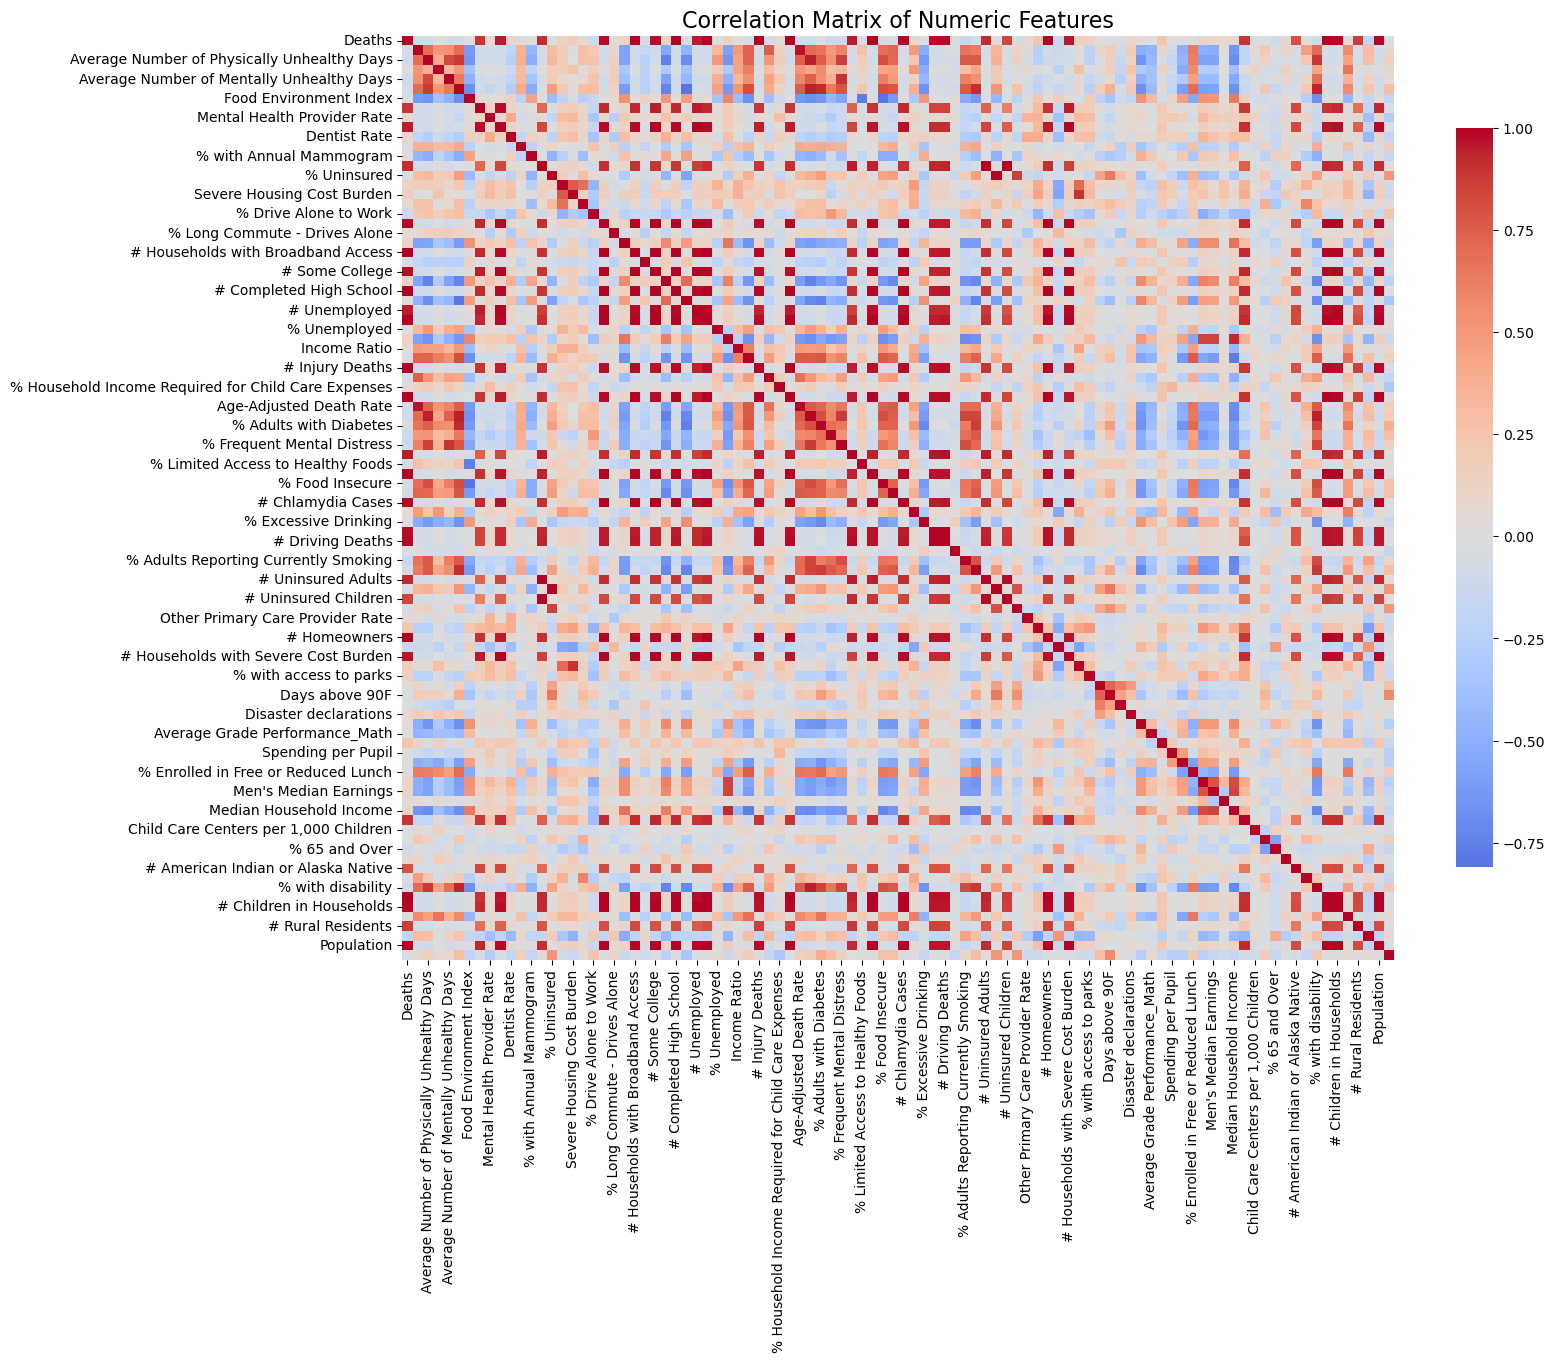

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features (exclude the target 'price')
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=["Life Expectancy"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    center=0, 
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()


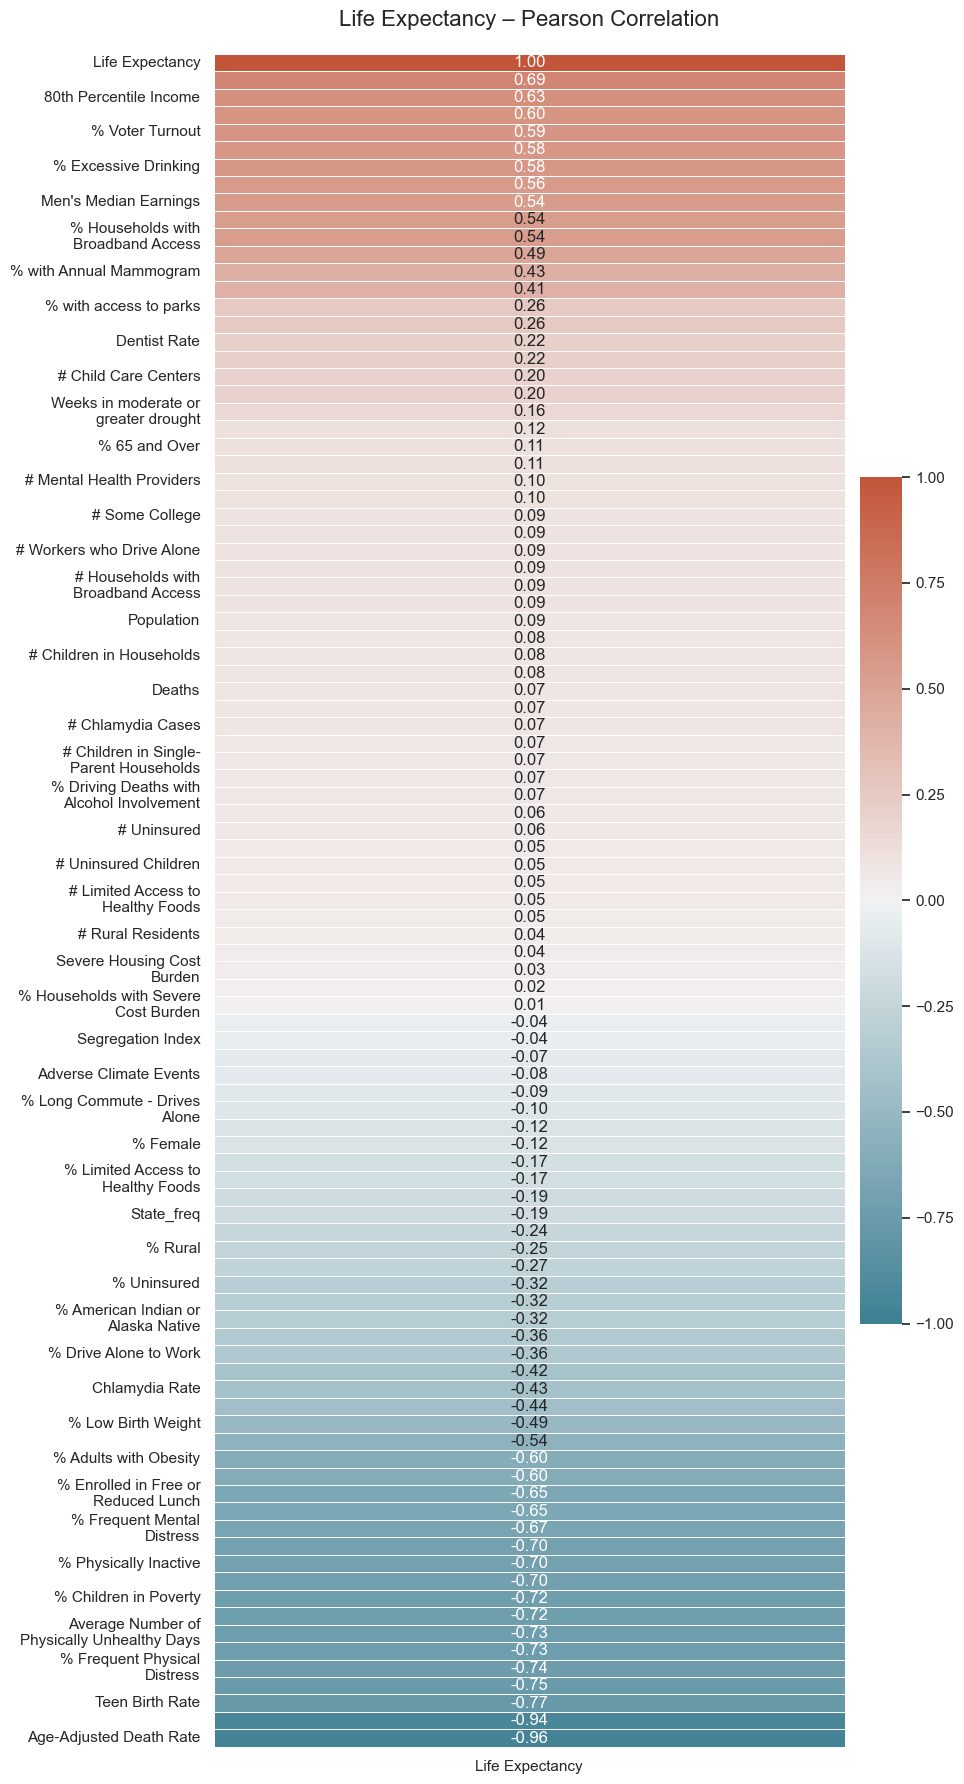

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# Compute correlations
num_cols = df.select_dtypes("number").columns
corr_vec = df[num_cols].corr()["Life Expectancy"].sort_values(ascending=False)

# Wrap long labels for readability
corr_vec.index = [textwrap.fill(label, 25) for label in corr_vec.index]

sns.set_theme(style="white")
sns.set(font_scale=1.0)

plt.figure(figsize=(10, 18))  # bigger, taller figure

ax = sns.heatmap(
    corr_vec.to_frame(),
    annot=True,
    fmt=".2f",
    vmin=-1, vmax=1,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    linewidths=.5,
    linecolor="white",
    cbar_kws={"shrink":0.5, "pad":0.02}
)

ax.set_title("Life Expectancy – Pearson Correlation", fontsize=16, pad=20)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


In [7]:
def select_top_features(df):
    """
    Returns a dataframe containing only the selected top predictors
    and drops all rows containing NaN in these columns.
    """

    selected_columns = [
        "80th Percentile Income",
        "% Voter Turnout",
        "% Excessive Drinking",
        "Men's Median Earnings", 
        "% Households with Broadband Access",
        "% with Annual Mammogram",
        "% with access to parks", 
        "% Teen Birth Rate",
        "% Frequent Physical Distress",
        "% Physically Inactive",
        "% Children in Poverty",
        "% Adults with Obesity",
        "% Low Birth Weight",
        "% Drive Alone to Work",
        "Life Expectancy"
    ]

    # Keep only columns that exist in the dataframe
    cols_present = [col for col in selected_columns if col in df.columns]

    # Subset the dataframe to only these columns
    df_selected = df[cols_present].copy()

    # Drop rows with ANY NaN in these columns
    df_clean = df_selected.dropna(axis=0, how="any")

    return df_clean


In [9]:
df = select_top_features(df)
print(df.head())


   80th Percentile Income  % Voter Turnout  % Excessive Drinking  \
0                116760.0        66.782918             21.408386   
1                117096.0        69.431934             21.412113   
2                111170.0        66.048988             19.497764   
3                150966.0        71.868005             23.037699   
4                184481.0        76.480870             18.182664   

   Men's Median Earnings  % Households with Broadband Access  \
0                59692.0                           81.676647   
1                54729.0                           83.784559   
2                50434.0                           83.716400   
3                72300.0                           89.049221   
4                79606.0                           92.960307   

   % with Annual Mammogram  % with access to parks  \
0                     48.0               31.169126   
1                     51.0                1.319357   
2                     44.0                4.

In [10]:
train_df = select_top_features(train_df)
eval_df=select_top_features(eval_df)
holdout_df=select_top_features(holdout_df)


print("   feature_engineered_train:", train_df.shape)
print("   feature_engineered_eval:", eval_df.shape)
print("   feature_engineered_holdout:", holdout_df.shape)

   feature_engineered_train: (1935, 14)
   feature_engineered_eval: (415, 14)
   feature_engineered_holdout: (422, 14)


In [ ]:
'''def add_income_interactions(df):#This function was added after SHAP in notebook 6 
    """
    Adds SHAP-identified interaction features:
      - income × physical inactivity
      - income × poverty
      - income × physical distress

    Returns the updated dataframe.
    """

    # Define required columns
    income_col = "80th Percentile Income"
    inactive_col = "% Physically Inactive"
    poverty_col = "% Children in Poverty"
    distress_col = "% Frequent Physical Distress"

    missing = [col for col in [income_col, inactive_col, poverty_col, distress_col] if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for interaction terms: {missing}")

    # Add interactions
    df["income_x_inactive"]  = df[income_col] * df[inactive_col]
    df["income_x_poverty"]   = df[income_col] * df[poverty_col]
    df["income_x_distress"]  = df[income_col] * df[distress_col]

    return df
'''

In [ ]:
'''train_df = add_income_interactions(train_df)
eval_df=add_income_interactions(eval_df)
holdout_df=add_income_interactions(holdout_df)'''

In [ ]:
train_df.to_csv("data/processed/feature_engineered_train.csv", index=False)
eval_df.to_csv("data/processed/feature_engineered_eval.csv", index=False)
holdout_df.to_csv("data/processed/feature_engineered_holdout.csv", index=False)